# Libraries

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


from PIL import Image, ImageColor
import cv2
import torchmetrics

import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch
from torch.utils.data import Dataset, DataLoader
import lightning as L
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp
from torch.utils.tensorboard import SummaryWriter


/Users/lexuanthang/miniconda3/envs/light/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/lexuanthang/miniconda3/envs/light/lib/python3.9/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <2D1B8D5C-7891-3680-9CF9-F771AE880676> /Users/lexuanthang/miniconda3/envs/light/lib/python3.9/site-packages/torchvision/image.so
  Expected in:     <36F46DB8-DB62-3926-8653-E332C34252FB> /Users/lexuanthang/miniconda3/envs/light/lib/python3.9/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
print(f"PyTorch version: {torch.__version__}")

# Check PyTorch has access to MPS (Metal Performance Shader, Apple's GPU architecture)
print(f"Is MPS (Metal Performance Shader) built? {torch.backends.mps.is_built()}")
print(f"Is MPS available? {torch.backends.mps.is_available()}")

# Set the device      
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")


PyTorch version: 2.5.1
Is MPS (Metal Performance Shader) built? True
Is MPS available? True
Using device: mps


In [3]:
# Set the device
device = "mps" if torch.backends.mps.is_available() else "cpu"

# Create data and send it to the device
x = torch.rand(size=(3, 4)).to(device)
x

tensor([[0.3282, 0.4775, 0.4622, 0.0999],
        [0.0206, 0.8790, 0.5607, 0.0366],
        [0.5065, 0.0053, 0.3103, 0.5418]], device='mps:0')

# Informations

In [4]:
project_dir = Path("/Users/lexuanthang/Library/CloudStorage/OneDrive-Personal/01_WORKING/02_cell_detection")
data_dir = project_dir / "Data/Labeling"
images_dir = data_dir / "P01_images"
masks_dir = data_dir / "P01_masks"

print("input image path: {} \ninput mask path: {}".format(images_dir, masks_dir))
CELL_CLASSES = [
    "Marcophage/Monocyte",
    "Neutrophil",
    "Eosinophil",
    "Lymphocyte",
    "Unknown cell/Debris",
    "Basophil",
]

trainsize = 256
train_transform = A.Compose([
    A.Resize(width=trainsize, height=trainsize),
    A.HorizontalFlip(),
    # A.RandomBrightnessContrast(),
    A.Blur(),
    A.Sharpen(),
    # A.RGBShift(),
    A.CoarseDropout(),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
    ToTensorV2(),
])

# Define color to class index mapping
label_colors = {
    (28, 230, 255): 1,  # Macrophage/Monocyte
    (255, 52, 255): 2,  # Neutrophil
    (255, 74, 70): 3,  # Eosinophil
    (0, 137, 65): 4,  # Lymphocyte
    (0, 111, 166): 5,  # Unknown cell/Debris
    (163, 0, 89): 6   # Basophil
}


input image path: /Users/lexuanthang/Library/CloudStorage/OneDrive-Personal/01_WORKING/02_cell_detection/Data/Labeling/P01_images 
input mask path: /Users/lexuanthang/Library/CloudStorage/OneDrive-Personal/01_WORKING/02_cell_detection/Data/Labeling/P01_masks


In [6]:
def check_files_exist(images_dir, masks_dir, image_prefix="P01_", mask_prefix="masks_P01_"):
    images = sorted(os.listdir(images_dir))
    masks = sorted(os.listdir(masks_dir))

    missing_masks = []

    for img_name in images:
        # Assuming the mask file has the same name as the image file but with a different prefix
        mask_name = img_name.replace(image_prefix, mask_prefix)
        if mask_name not in masks:
            missing_masks.append(mask_name)
            print(f"Missing mask for image: {img_name}")

    if not missing_masks:
        print("All image files have corresponding mask files.")
    else:
        print(f"Total missing masks: {len(missing_masks)}")

check_files_exist(images_dir, masks_dir)

All image files have corresponding mask files.


# Dataset

In [7]:
class CellDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        """
        Args:
            images_dir (string): Path to the directory containing images.
            masks_dir (string): Path to the directory containing corresponding masks.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.images = sorted(os.listdir(images_dir))
        self.masks = sorted(os.listdir(masks_dir))
        
        # Create a dictionary to map image names to mask names
        self.image_mask_map = {img_name: self.find_matching_mask(img_name) for img_name in self.images}

    def find_matching_mask(self, img_name):
        # Assuming the mask file has the same name as the image file but with a different prefix
        mask_name = img_name.replace("P01_", "masks_P01_")
        if mask_name in self.masks:
            return mask_name
        else:
            raise ValueError(f"No matching mask found for image {img_name}")

    def __len__(self):
        """
        Return the total number of samples.
        """
        return len(self.images)

    def __getitem__(self, idx):
        """
        Generate one sample of data.
        """
        img_name = self.images[idx]
        mask_name = self.image_mask_map[img_name]
        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, mask_name)

        image = Image.open(img_path).convert('RGB')
        image = np.array(image)
        mask = Image.open(mask_path).convert('RGB')

        # convert mask colors to classes
        mask = self.convert_mask(mask)

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]
        # print(f"Loaded image: {img_name}, mask: {mask_name}")  # Debug print
        return image.float(), mask.long()

    def convert_mask(self, mask):
        """Convert RGB mask to a class map."""
        mask_array = np.array(mask)
        class_map = np.zeros(mask_array.shape[:2], dtype=np.int32)

        for color, class_id in label_colors.items():
            matches = (mask_array == color).all(axis=-1)
            class_map[matches] = class_id

        return class_map

In [8]:
from torch.utils.data import random_split
# Initialize dataset
full_dataset = CellDataset(images_dir,masks_dir,transform=train_transform)

# split dataset
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
tes_size = len(full_dataset) - train_size - val_size
print("train size: {}, val size: {}, test size: {}".format(train_size, val_size, tes_size))
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, tes_size])
print("train size: {}, val size: {}, test size: {}".format(len(train_dataset), len(val_dataset), len(test_dataset)))

train size: 62, val size: 13, test size: 15
train size: 62, val size: 13, test size: 15


In [9]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

Training Dataset:


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 256, 256])


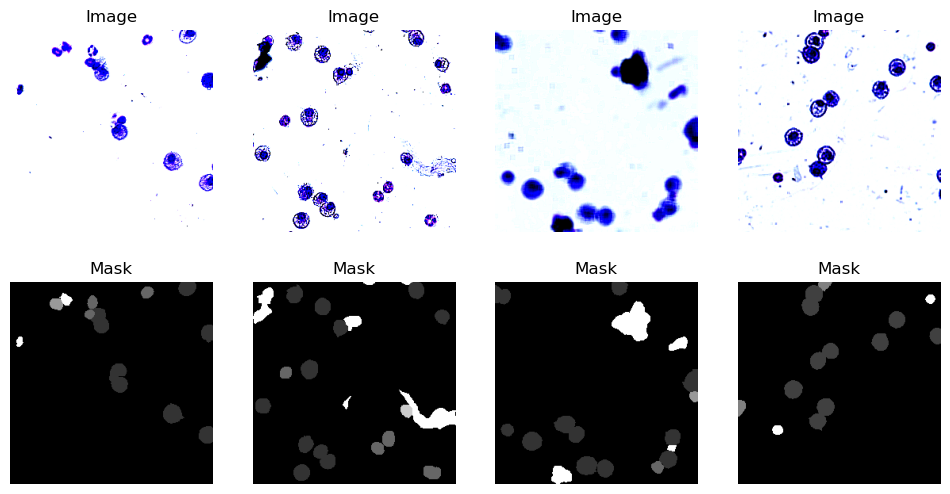

Validation Dataset:


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 256, 256])


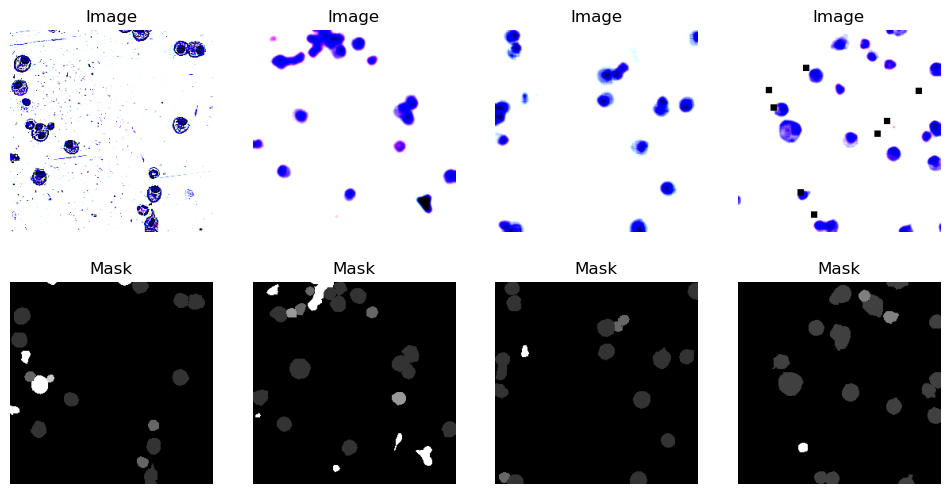

Test Dataset:


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 256, 256])


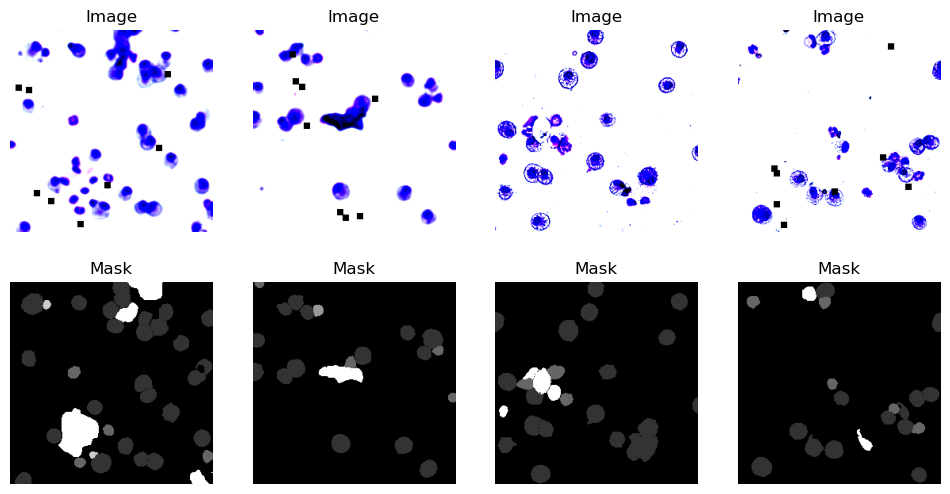

In [12]:
def check_dataloader(dataloader, num_samples_to_display=4):
    # Get a single batch from the dataloader
    sample_batch = next(iter(dataloader))

    # Extract the image and mask
    images, masks = sample_batch

    # Print the shapes of the images and masks in the batch
    print(f"Image batch shape: {images.shape}")
    print(f"Mask batch shape: {masks.shape}")

    # Plot the first few images and masks
    plt.figure(figsize=(12, 6))
    for i in range(num_samples_to_display):
        image = images[i].permute(1, 2, 0).numpy()  # Convert from (C, H, W) to (H, W, C)
        mask = masks[i].numpy()

        plt.subplot(2, num_samples_to_display, i + 1)
        plt.imshow(image)
        plt.title("Image")
        plt.axis('off')

        plt.subplot(2, num_samples_to_display, i + 1 + num_samples_to_display)
        plt.imshow(mask, cmap='gray')
        plt.title("Mask")
        plt.axis('off')

    plt.show()
    return images, masks

# Check training dataset
print("Training Dataset:")
image_train_batch, mask_train_batch = check_dataloader(train_loader)
# Check validation dataset
print("Validation Dataset:")
image_val_batch, mask_val_batch = check_dataloader(val_loader)

# Check test dataset
print("Test Dataset:")
image_test_batch, mask_test_batch = check_dataloader(test_loader)

# Defining the Lighning Module

In [11]:
from torchmetrics.segmentation import MeanIoU
from torchmetrics.classification import MulticlassAccuracy as Accuracy


class UNetLightningModule(L.LightningModule):
    def __init__(self):
        super(UNetLightningModule, self).__init__()
        self.model = smp.Unet(
                            encoder_name="resnet34",        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
                            encoder_weights="imagenet",     # use `imagenet` pre-trained weights for encoder initialization
                            in_channels=3,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
                            classes=7,                      # model output channels (number of classes in your dataset)
                            )
        self.criterion = nn.CrossEntropyLoss()
        self.train_accuracy = Accuracy(num_classes=7, average='macro')  # Độ chính xác cho huấn luyện
        self.val_accuracy = Accuracy(num_classes=7, average='macro')  # Độ chính xác cho xác thực
        self.test_accuracy = Accuracy(num_classes=7, average='macro')  # Độ chính xác cho kiểm tra        
        self.metric = MeanIoU(num_classes=7)
        self.writer = SummaryWriter("logs/unet_model")  # Tạo đối tượng SummaryWriter
        
    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, masks = batch
        images, masks = images.to(self.device), masks.to(self.device)
        outputs = self(images)
        loss = self.criterion(outputs, masks)

        
        preds = torch.argmax(outputs, dim=1).squeeze()

        # Tính toán độ chính xác
        acc = self.train_accuracy(preds, masks)
        iou = self.metric(preds, masks)  # Tính toán IoU
        
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', acc, prog_bar=True)
        self.log('train_iou', iou, prog_bar=True)
        
        # Ghi lại các chỉ số vào TensorBoard
        self.writer.add_scalar('Loss/train', loss, self.current_epoch)
        self.writer.add_scalar('Accuracy/train', acc, self.current_epoch)
        self.writer.add_scalar('IoU/train', iou, self.current_epoch)        
        return loss

    def validation_step(self, batch, batch_idx):
        images, masks = batch
        images, masks = images.to(self.device), masks.to(self.device)
        outputs = self(images)
        loss = self.criterion(outputs, masks)
        
        preds = torch.argmax(outputs, dim=1).squeeze()

        # Tính toán độ chính xác
        acc = self.val_accuracy(preds, masks)
        iou = self.metric(preds, masks)  # Tính toán IoU
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
        self.log('val_iou', iou, prog_bar=True)

        # Ghi lại các chỉ số vào TensorBoard
        self.writer.add_scalar('Loss/val', loss, self.current_epoch)
        self.writer.add_scalar('Accuracy/val', acc, self.current_epoch)
        self.writer.add_scalar('IoU/val', iou, self.current_epoch)
        return loss
    
    def test_step(self, batch, batch_idx):
        images, masks = batch
        images, masks = images.to(self.device), masks.to(self.device)
        outputs = self(images)
        loss = self.criterion(outputs, masks)  # CrossEntropyLoss yêu cầu đầu ra và mục tiêu có kích thước phù hợp

        # Chuyển đổi đầu ra sang nhị phân bằng cách lấy lớp có xác suất cao nhất
        preds = torch.argmax(outputs, dim=1)

        # Tính toán độ chính xác
        acc = self.test_accuracy(preds, masks)
        iou = self.metric(preds, masks)  # Tính toán IoU
        
        self.log('test_loss', loss)
        self.log('test_acc', acc)
        self.log('test_iou', iou)
        return loss
    
    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        return optimizer
    
    def on_train_end(self):
        self.writer.close()  # Đóng SummaryWriter khi kết thúc huấn luyện

# Training model

In [14]:
# Initialize the LightningModule
model = UNetLightningModule()

# Initialize the Trainer with MPS support
trainer = L.Trainer(max_epochs=100, devices=1, accelerator='mps')

# Train the model
trainer.fit(model, train_loader, val_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name           | Type               | Params | Mode 
--------------------------------------------------------------
0 | model          | Unet               | 24.4 M | train
1 | criterion      | CrossEntropyLoss   | 0      | train
2 | train_accuracy | MulticlassAccuracy | 0      | train
3 | val_accuracy   | MulticlassAccuracy | 0      | train
4 | test_accuracy  | MulticlassAccuracy | 0      | train
5 | metric         | MeanIoU            | 0      | train
--------------------------------------------------------------
24.4 M    Trainable params
0         Non-trainable params
24.4 M    Total params
97.749    Total estimated model params size (MB)
193       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/lexuanthang/miniconda3/envs/light/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


/Users/lexuanthang/miniconda3/envs/light/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/lexuanthang/miniconda3/envs/light/lib/python3.9/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 84:  75%|███████▌  | 6/8 [00:07<00:02,  0.80it/s, v_num=0, train_loss=0.0248, train_acc=0.759, train_iou=0.679, val_loss=0.0671, val_acc=0.586, val_iou=-2.34e+6]       

RuntimeError: MPS backend out of memory (MPS allocated: 2.19 GB, other allocations: 15.76 GB, max allowed: 18.13 GB). Tried to allocate 196.00 MB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

In [20]:
# Test the model
trainer.test(dataloaders=test_loader)

/Users/lexuanthang/miniconda3/envs/light/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:145: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
Restoring states from the checkpoint path at logs/unet_model/version_1/checkpoints/epoch=99-step=800.ckpt
Loaded model weights from the checkpoint at logs/unet_model/version_1/checkpoints/epoch=99-step=800.ckpt
/Users/lexuanthang/miniconda3/envs/light/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 2/2 [00:01<00:00,  1.71it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.5517359375953674     │
│         test_iou          │    0.5803204774856567     │
│         test_loss         │    0.0960472896695137     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.0960472896695137,
  'test_acc': 0.5517359375953674,
  'test_iou': 0.5803204774856567}]